In [ ]:
import os
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter
from src.tester import Tester

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

In [4]:
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor

In [5]:
load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [6]:
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [7]:
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
from src.items import Item

In [9]:
%matplotlib inline

# Loading the pkl files

In [ ]:
with open('data/train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('data/test.pkl', 'rb') as file:
    test = pickle.load(file)

In [11]:
print(train[0].prompt)

How much does this cost to the nearest dollar?

2 Pack JBL Clip 4 Waterproof Wireless Audio Bluetooth Speaker Bundle (Black)
IT'S ALL ABOUT THE SOUND! Music here, there, everywhere. Clip and play, cool, portable, and waterproof! The vibrant fresh looking JBL Clip 4 delivers surprisingly rich JBL Original Pro Sound in a compact package. The unique oval shape fits easy in your hand. Fully wrapped in colorful fabrics with expressive details inspired by current street fashion, it’s easy to match your style. The fully integrated carabiner hooks instantly to bags, belts, or buckles, to bring your favorite tunes anywhere. Waterproof, dustproof, and up to 10 hours of playtime, it’s rugged enough to tag along wherever you explore. This Exclusive Bundle includes two JBL Clip 4 speakers .Cool,

Price is $98.00


In [12]:
print(train[0].price)

97.66


In [53]:
train[0].details

'{"Product Dimensions": "2 x 4 x 3 inches", "Item Weight": "0.53 Pounds", "Item model number": "CP4BUN02", "Batteries": "1 Lithium Ion batteries required.", "Best Sellers Rank": {"Electronics": 28022, "Portable Bluetooth Speakers": 899}, "Date First Available": "May 26, 2022", "Manufacturer": "JBL", "Number Of Items": "1", "Brand": "JBL", "Model Name": "Clip4black", "Speaker Type": "Portable Bluetooth Speakers", "Connectivity Technology": "USB", "Special Feature": "Portable, Waterproof, Dustproof"}'

In [ ]:
train[0].features

{'Product Dimensions': '2 x 4 x 3 inches',
 'Item Weight': '0.53 Pounds',
 'Item model number': 'CP4BUN02',
 'Batteries': '1 Lithium Ion batteries required.',
 'Best Sellers Rank': {'Electronics': 28022,
  'Portable Bluetooth Speakers': 899},
 'Date First Available': 'May 26, 2022',
 'Manufacturer': 'JBL',
 'Number Of Items': '1',
 'Brand': 'JBL',
 'Model Name': 'Clip4black',
 'Speaker Type': 'Portable Bluetooth Speakers',
 'Connectivity Technology': 'USB',
 'Special Feature': 'Portable, Waterproof, Dustproof'}

In [14]:
# Create a new "features" field on items, and populate it with json parsed from the details dict

for item in train:
    item.features = json.loads(item.details)
for item in test:
    item.features = json.loads(item.details)

In [55]:
train[0].features.values()

dict_values(['2 x 4 x 3 inches', '0.53 Pounds', 'CP4BUN02', '1 Lithium Ion batteries required.', {'Electronics': 28022, 'Portable Bluetooth Speakers': 899}, 'May 26, 2022', 'JBL', '1', 'JBL', 'Clip4black', 'Portable Bluetooth Speakers', 'USB', 'Portable, Waterproof, Dustproof'])

In [15]:
train[0].features.keys()

dict_keys(['Product Dimensions', 'Item Weight', 'Item model number', 'Batteries', 'Best Sellers Rank', 'Date First Available', 'Manufacturer', 'Number Of Items', 'Brand', 'Model Name', 'Speaker Type', 'Connectivity Technology', 'Special Feature'])

In [16]:
def get_weight(item):
    weight_str = item.features.get('Item Weight')
    if weight_str:
        parts = weight_str.split(' ')
        amount = float(parts[0])
        unit = parts[1].lower()
        if unit=="pounds":
            return amount
        elif unit=="ounces":
            return amount / 16
        elif unit=="grams":
            return amount / 453.592
        elif unit=="milligrams":
            return amount / 453592
        elif unit=="kilograms":
            return amount / 0.453592
        elif unit=="hundredths" and parts[2].lower()=="pounds":
            return amount / 100
        else:
            print(weight_str)
    return None

In [17]:
weights = [get_weight(t) for t in train]
weights = [w for w in weights if w]

In [18]:
average_weight = sum(weights)/len(weights)
average_weight

13.656957177463129

In [19]:
def get_weight_with_default(item):
    weight = get_weight(item)
    return weight or average_weight

In [ ]:
#if a product is in multiple rankings, take the average
def get_rank(item):
    rank_dict = item.features.get("Best Sellers Rank")
    if rank_dict:
        ranks = rank_dict.values()
        return sum(ranks)/len(ranks)
    return None

In [21]:
ranks = [get_rank(t) for t in train]
ranks = [r for r in ranks if r]
average_rank = sum(ranks)/len(ranks)
average_rank

384653.74234209285

In [22]:
def get_rank_with_default(item):
    rank = get_rank(item)
    return rank or average_rank

In [23]:
def get_text_length(item):
    return len(item.test_prompt())

In [24]:
brands = Counter()
for t in train:
    brand = t.features.get("Brand")
    if brand:
        brands[brand]+=1

brands.most_common(40)

[('HP', 5469),
 ('Power Stop', 3583),
 ('Dell', 3236),
 ('Detroit Axle', 2632),
 ('Lenovo', 2430),
 ('Dorman', 2088),
 ('SAMSUNG', 1758),
 ('BUYAUTOPARTS!', 1713),
 ('ACDelco', 1560),
 ('ASUS', 1393),
 ('Evan Fischer', 1386),
 ('Canon', 1255),
 ('Sony', 1251),
 ('Callahan BRAKE PARTS', 1127),
 ('Kohler', 1108),
 ('R1 Concepts', 1082),
 ('CURT', 1053),
 ('WeatherTech', 1005),
 ('Rareelectrical', 968),
 ('Coverking', 922),
 ('Kingston Brass', 863),
 ('Garage-Pro', 842),
 ('Spectra Premium', 840),
 ('Moen', 834),
 ('Auto Dynasty', 818),
 ('Apple', 779),
 ('K&N', 774),
 ('Cardone', 772),
 ('DELTA FAUCET', 771),
 ('Generic', 764),
 ('APS', 760),
 ('EBC Brakes', 750),
 ('GM', 733),
 ('Walker', 722),
 ('Intel', 651),
 ('AKKON', 631),
 ('TYC', 621),
 ('DEWALT', 615),
 ('SPEC-D TUNING', 610),
 ('Westin', 605)]

In [25]:
TOP_ELECTRONICS_BRANDS = ["hp", "dell", "lenovo", "samsung", "asus", "sony", "canon", "apple", "intel"]
def is_top_electronics_brand(item):
    brand = item.features.get("Brand")
    return brand and brand.lower() in TOP_ELECTRONICS_BRANDS

In [26]:
def get_features(item):
    return {
        "weight": get_weight_with_default(item),
        "rank": get_rank_with_default(item),
        "text_length": get_text_length(item),
        "is_top_electronics_brand": 1 if is_top_electronics_brand(item) else 0
    }

In [27]:
get_features(train[0])

{'weight': 0.53,
 'rank': 14460.5,
 'text_length': 805,
 'is_top_electronics_brand': 0}

In [28]:
def list_to_dataframe(items):
    features = [get_features(item) for item in items]
    df = pd.DataFrame(features)
    df['price'] = [item.price for item in items]
    return df

train_df = list_to_dataframe(train)
test_df = list_to_dataframe(test[:250])

In [ ]:
np.random.seed(42)

feature_columns = ['weight', 'rank', 'text_length', 'is_top_electronics_brand']

X_train = train_df[feature_columns]
y_train = train_df['price']
X_test = test_df[feature_columns]
y_test = test_df['price']

model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef}")
print(f"Intercept: {model.intercept_}")

# Predict the test set and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

weight: 0.2676373264769923
rank: 5.188889373210722e-05
text_length: -0.0095358378691425
is_top_electronics_brand: 194.48672695750096
Intercept: 196.5528793444176
Mean Squared Error: 36921.954992278785
R-squared Score: 0.07149409673059859


In [30]:
def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return model.predict(features_df)[0]

1: Guess: $198.90 Truth: $48.95 Error: $149.95 SLE: 1.92 Item: Disney Animators' Littles Rapunzel Surpr...
2: Guess: $191.73 Truth: $9.99 Error: $181.74 SLE: 8.20 Item: TIKROUND Youngtown Movement for Clock Re...
3: Guess: $255.07 Truth: $167.98 Error: $87.09 SLE: 0.17 Item: ARIES 205045 3-Inch Round Black Steel Ne...
4: Guess: $216.68 Truth: $166.08 Error: $50.60 SLE: 0.07 Item: Filterbuy 16x22x5 Air Filter MERV 13 Opt...
5: Guess: $208.90 Truth: $44.30 Error: $164.60 SLE: 2.35 Item: THE NORTH FACE Women's Etip¿ Gloves
6: Guess: $205.11 Truth: $299.99 Error: $94.88 SLE: 0.14 Item: Parrot Uncle Ceiling Fans with Lights an...
7: Guess: $189.45 Truth: $6.39 Error: $183.06 SLE: 10.56 Item: 50Pcs Aesthetic Stickers for Water Bottl...
8: Guess: $190.46 Truth: $639.95 Error: $449.49 SLE: 1.46 Item: Tamron B028N 18-400 mm f3.5-6.3 Di II VC...
9: Guess: $212.55 Truth: $530.00 Error: $317.45 SLE: 0.83 Item: Freedom OffRoad Uni-Ball Front Upper Con...
10: Guess: $202.01 Truth: $59.95 Error: $142

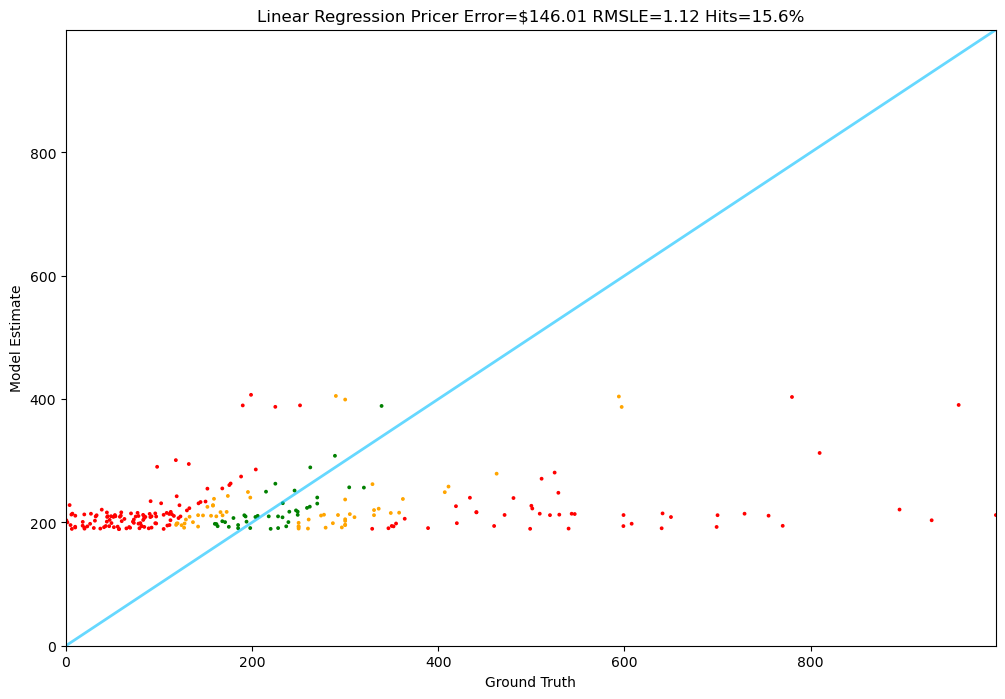

In [31]:
Tester.test(linear_regression_pricer, data=test)

In [32]:
prices = np.array([float(item.price) for item in train])
documents = [item.test_prompt() for item in train]

In [33]:
np.random.seed(42)
vectorizer = CountVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(documents)
regressor = LinearRegression()
regressor.fit(X, prices)

LinearRegression()

In [34]:
def bow_lr_pricer(item):
    x = vectorizer.transform([item.test_prompt()])
    return max(regressor.predict(x)[0], 0)

1: Guess: $134.26 Truth: $48.95 Error: $85.31 SLE: 0.99 Item: Disney Animators' Littles Rapunzel Surpr...
2: Guess: $82.55 Truth: $9.99 Error: $72.56 SLE: 4.11 Item: TIKROUND Youngtown Movement for Clock Re...
3: Guess: $351.32 Truth: $167.98 Error: $183.34 SLE: 0.54 Item: ARIES 205045 3-Inch Round Black Steel Ne...
4: Guess: $134.84 Truth: $166.08 Error: $31.24 SLE: 0.04 Item: Filterbuy 16x22x5 Air Filter MERV 13 Opt...
5: Guess: $165.21 Truth: $44.30 Error: $120.91 SLE: 1.69 Item: THE NORTH FACE Women's Etip¿ Gloves
6: Guess: $248.61 Truth: $299.99 Error: $51.38 SLE: 0.04 Item: Parrot Uncle Ceiling Fans with Lights an...
7: Guess: $36.40 Truth: $6.39 Error: $30.01 SLE: 2.63 Item: 50Pcs Aesthetic Stickers for Water Bottl...
8: Guess: $476.66 Truth: $639.95 Error: $163.29 SLE: 0.09 Item: Tamron B028N 18-400 mm f3.5-6.3 Di II VC...
9: Guess: $320.23 Truth: $530.00 Error: $209.77 SLE: 0.25 Item: Freedom OffRoad Uni-Ball Front Upper Con...
10: Guess: $101.29 Truth: $59.95 Error: $41.34 SL

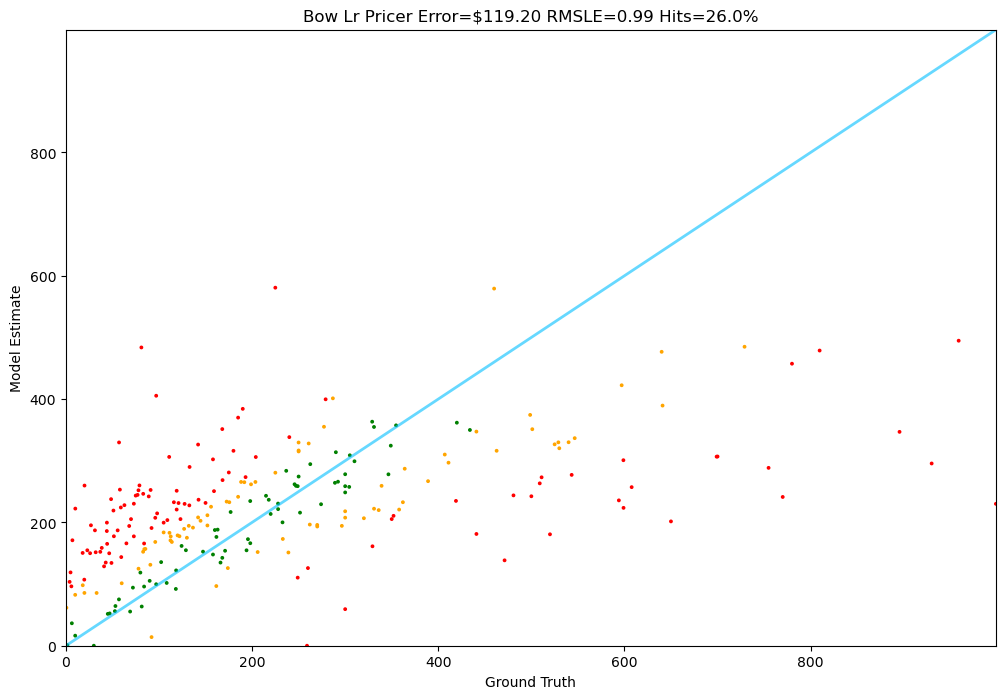

In [35]:
Tester.test(bow_lr_pricer, data=test)

In [36]:
np.random.seed(42)
processed_docs = [simple_preprocess(doc) for doc in documents]
w2v_model = Word2Vec(sentences=processed_docs, vector_size=400, window=5, min_count=1, workers=8)

In [37]:
def document_vector(doc):
    doc_words = simple_preprocess(doc)
    word_vectors = [w2v_model.wv[word] for word in doc_words if word in w2v_model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(w2v_model.vector_size)

X_w2v = np.array([document_vector(doc) for doc in documents])

In [38]:
word2vec_lr_regressor = LinearRegression()
word2vec_lr_regressor.fit(X_w2v, prices)

LinearRegression()

In [39]:
def word2vec_lr_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, word2vec_lr_regressor.predict([doc_vector])[0])

1: Guess: $173.06 Truth: $48.95 Error: $124.11 SLE: 1.56 Item: Disney Animators' Littles Rapunzel Surpr...
2: Guess: $29.79 Truth: $9.99 Error: $19.80 SLE: 1.06 Item: TIKROUND Youngtown Movement for Clock Re...
3: Guess: $360.87 Truth: $167.98 Error: $192.89 SLE: 0.58 Item: ARIES 205045 3-Inch Round Black Steel Ne...
4: Guess: $102.07 Truth: $166.08 Error: $64.01 SLE: 0.23 Item: Filterbuy 16x22x5 Air Filter MERV 13 Opt...
5: Guess: $198.15 Truth: $44.30 Error: $153.85 SLE: 2.19 Item: THE NORTH FACE Women's Etip¿ Gloves
6: Guess: $252.48 Truth: $299.99 Error: $47.51 SLE: 0.03 Item: Parrot Uncle Ceiling Fans with Lights an...
7: Guess: $0.00 Truth: $6.39 Error: $6.39 SLE: 4.00 Item: 50Pcs Aesthetic Stickers for Water Bottl...
8: Guess: $439.06 Truth: $639.95 Error: $200.89 SLE: 0.14 Item: Tamron B028N 18-400 mm f3.5-6.3 Di II VC...
9: Guess: $338.18 Truth: $530.00 Error: $191.82 SLE: 0.20 Item: Freedom OffRoad Uni-Ball Front Upper Con...
10: Guess: $149.31 Truth: $59.95 Error: $89.36 SLE

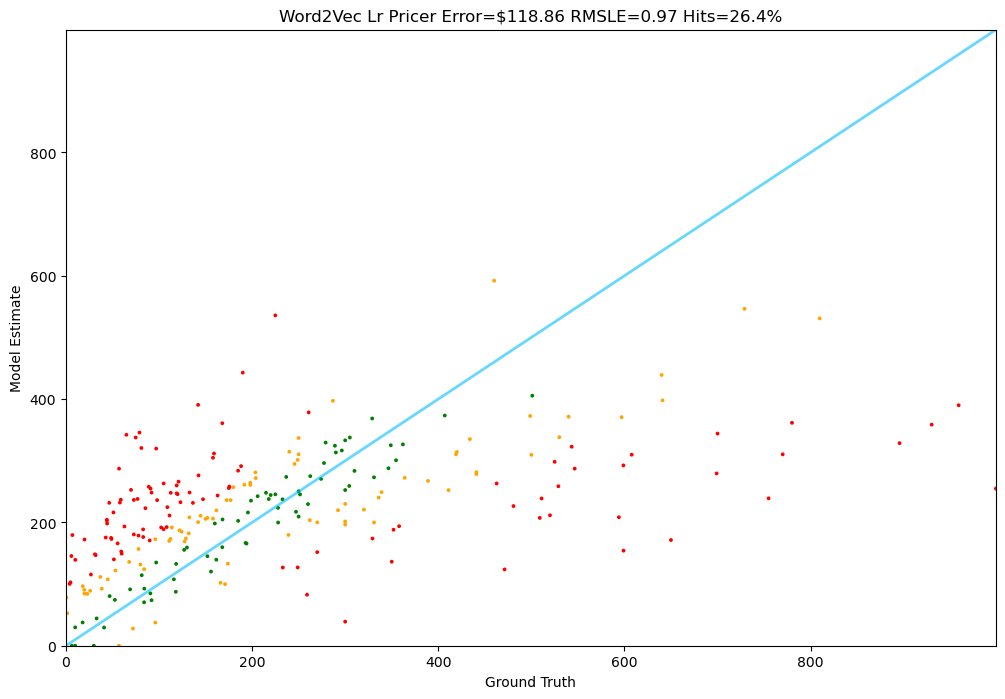

In [40]:
Tester.test(word2vec_lr_pricer, data=test)

In [41]:
np.random.seed(42)
svr_regressor = LinearSVR()
svr_regressor.fit(X_w2v, prices)

LinearSVR()

In [42]:
def svr_pricer(item):
    np.random.seed(42)
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(float(svr_regressor.predict([doc_vector])[0]),0)

1: Guess: $137.52 Truth: $48.95 Error: $88.57 SLE: 1.04 Item: Disney Animators' Littles Rapunzel Surpr...
2: Guess: $8.81 Truth: $9.99 Error: $1.18 SLE: 0.01 Item: TIKROUND Youngtown Movement for Clock Re...
3: Guess: $319.01 Truth: $167.98 Error: $151.03 SLE: 0.41 Item: ARIES 205045 3-Inch Round Black Steel Ne...
4: Guess: $81.63 Truth: $166.08 Error: $84.45 SLE: 0.50 Item: Filterbuy 16x22x5 Air Filter MERV 13 Opt...
5: Guess: $148.05 Truth: $44.30 Error: $103.75 SLE: 1.42 Item: THE NORTH FACE Women's Etip¿ Gloves
6: Guess: $210.94 Truth: $299.99 Error: $89.05 SLE: 0.12 Item: Parrot Uncle Ceiling Fans with Lights an...
7: Guess: $0.00 Truth: $6.39 Error: $6.39 SLE: 4.00 Item: 50Pcs Aesthetic Stickers for Water Bottl...
8: Guess: $330.11 Truth: $639.95 Error: $309.84 SLE: 0.44 Item: Tamron B028N 18-400 mm f3.5-6.3 Di II VC...
9: Guess: $281.22 Truth: $530.00 Error: $248.78 SLE: 0.40 Item: Freedom OffRoad Uni-Ball Front Upper Con...
10: Guess: $113.33 Truth: $59.95 Error: $53.38 SLE: 0.

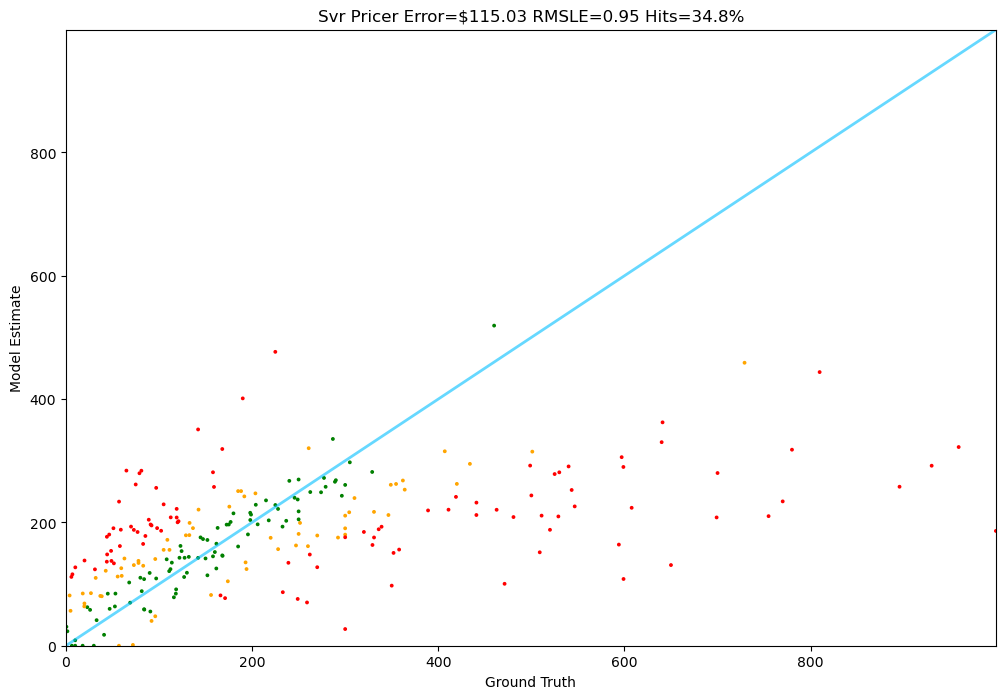

In [43]:
Tester.test(svr_pricer, data=test)

In [44]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=8)
rf_model.fit(X_w2v, prices)

RandomForestRegressor(n_jobs=8, random_state=42)

In [45]:
def random_forest_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, rf_model.predict([doc_vector])[0])

1: Guess: $102.53 Truth: $48.95 Error: $53.58 SLE: 0.53 Item: Disney Animators' Littles Rapunzel Surpr...
2: Guess: $72.75 Truth: $9.99 Error: $62.76 SLE: 3.62 Item: TIKROUND Youngtown Movement for Clock Re...
3: Guess: $169.69 Truth: $167.98 Error: $1.71 SLE: 0.00 Item: ARIES 205045 3-Inch Round Black Steel Ne...
4: Guess: $156.08 Truth: $166.08 Error: $10.00 SLE: 0.00 Item: Filterbuy 16x22x5 Air Filter MERV 13 Opt...
5: Guess: $245.12 Truth: $44.30 Error: $200.82 SLE: 2.86 Item: THE NORTH FACE Women's Etip¿ Gloves
6: Guess: $187.81 Truth: $299.99 Error: $112.18 SLE: 0.22 Item: Parrot Uncle Ceiling Fans with Lights an...
7: Guess: $13.07 Truth: $6.39 Error: $6.68 SLE: 0.41 Item: 50Pcs Aesthetic Stickers for Water Bottl...
8: Guess: $608.08 Truth: $639.95 Error: $31.87 SLE: 0.00 Item: Tamron B028N 18-400 mm f3.5-6.3 Di II VC...
9: Guess: $430.08 Truth: $530.00 Error: $99.92 SLE: 0.04 Item: Freedom OffRoad Uni-Ball Front Upper Con...
10: Guess: $134.54 Truth: $59.95 Error: $74.59 SLE: 0

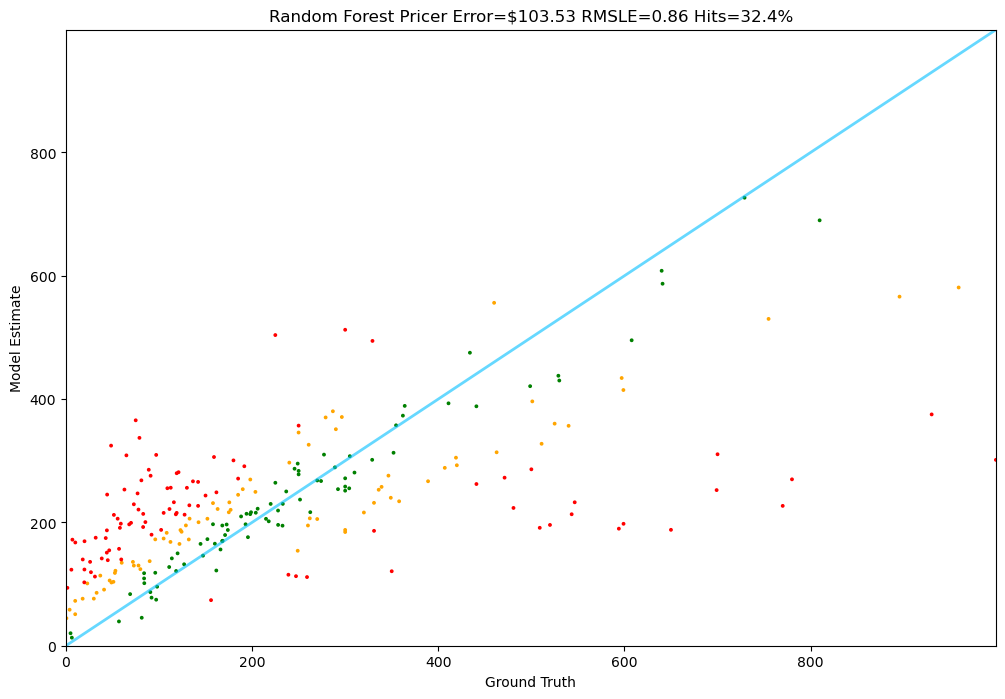

In [46]:
Tester.test(random_forest_pricer, data=test)

### ML Models Performance Summary

The following table ranks the performance of the models run on the `test.pkl` data, from the most successful (lowest error) to the least successful.

| Model | Average Error (Pricer Error) | RMSLE | Hits (%) |
| :--- | :--- | :--- | :--- |
| **RandomForestRegressor** | **$103.53** | **0.86** | **%32.4** |
| SVR (Support Vector Regressor) | $115.03 | 0.95 | %34.8 |
| Word2Vector + Linear Regression | $118.86 | 0.97 | %26.4 |
| Bags of Word + Linear Regression | $119.20 | 0.99 | %26 |
| Feature Engineering + Linear Regression | $146.00 | 1.12 | %15.6 |
